<a href="https://colab.research.google.com/github/Sukriti-124/aqua-safe/blob/main/aqua_safe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setting up Dataset

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sukritisrivastava12","key":"30fa8b940f2a1c0ac8876a0d01eca613"}'}

In [2]:
! mkdir -p ~/.kaggle

In [3]:
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
! ls -la ~/.kaggle


total 16
drwxr-xr-x 2 root root 4096 Jan 13 01:51 .
drwx------ 1 root root 4096 Jan 13 01:51 ..
-rw------- 1 root root   75 Jan 13 01:51 kaggle.json


In [5]:
! kaggle datasets download -d adityakadiwal/water-potability

Dataset URL: https://www.kaggle.com/datasets/adityakadiwal/water-potability
License(s): CC0-1.0
  0% 0.00/251k [00:00<?, ?B/s]
100% 251k/251k [00:00<00:00, 673MB/s]


In [6]:
! unzip water-potability.zip

Archive:  water-potability.zip
  inflating: water_potability.csv    


In [7]:
import pandas as pd
water_dataset = pd.read_csv('water_potability.csv')
water_dataset.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


# Dataset Exploration

In [8]:
water_dataset.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [9]:
water_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [10]:
#checking null values in dataset
water_dataset.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


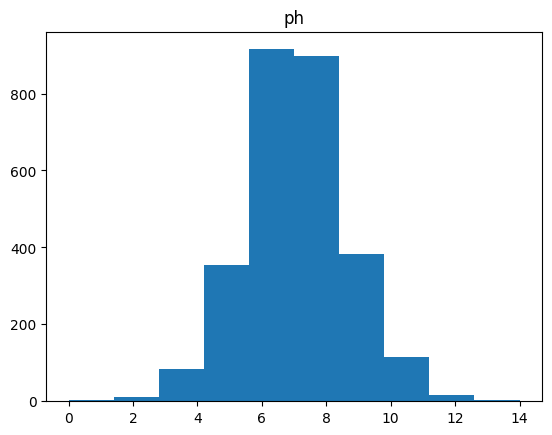

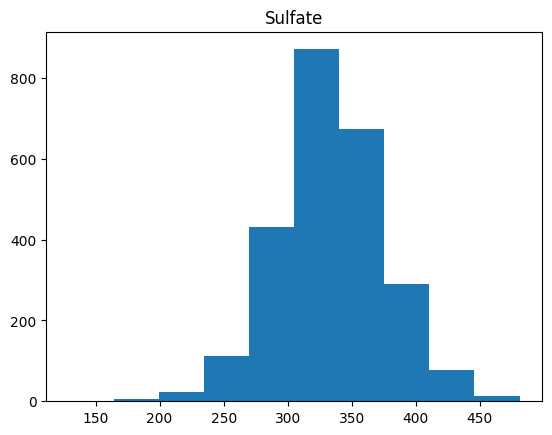

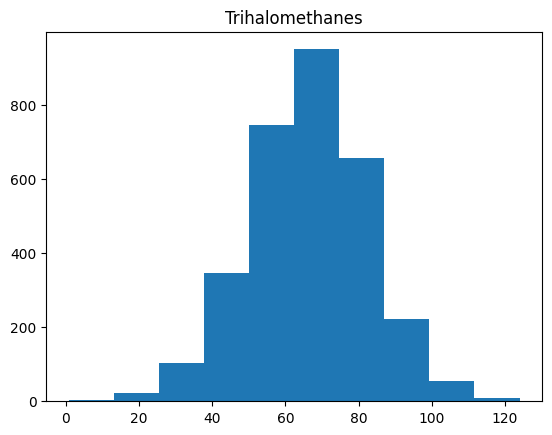

In [11]:
import matplotlib.pyplot as plt
missing_columns = ['ph', 'Sulfate', 'Trihalomethanes']
for column in missing_columns:
  plt.hist(water_dataset[column])
  plt.title(column)
  plt.show()

In [12]:
"""
replacing ph with mean since distribution is uniform and replacing Sulfate and
and Trihalomethanes wwitg median since distribution is skewed.
"""
water_dataset['ph'] = water_dataset['ph'].fillna(water_dataset['ph'].mean())
water_dataset['Sulfate'] = water_dataset['Sulfate'].fillna(water_dataset['Sulfate'].median())
water_dataset['Trihalomethanes'] = water_dataset['Trihalomethanes'].fillna(water_dataset['Trihalomethanes'].median())
water_dataset.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [13]:
water_dataset.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.608364,426.205111,14.284970,66.407478,3.966786,0.390110
std,1.469956,32.879761,8768.570828,1.583085,36.143851,80.824064,3.308162,15.769958,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.080795,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


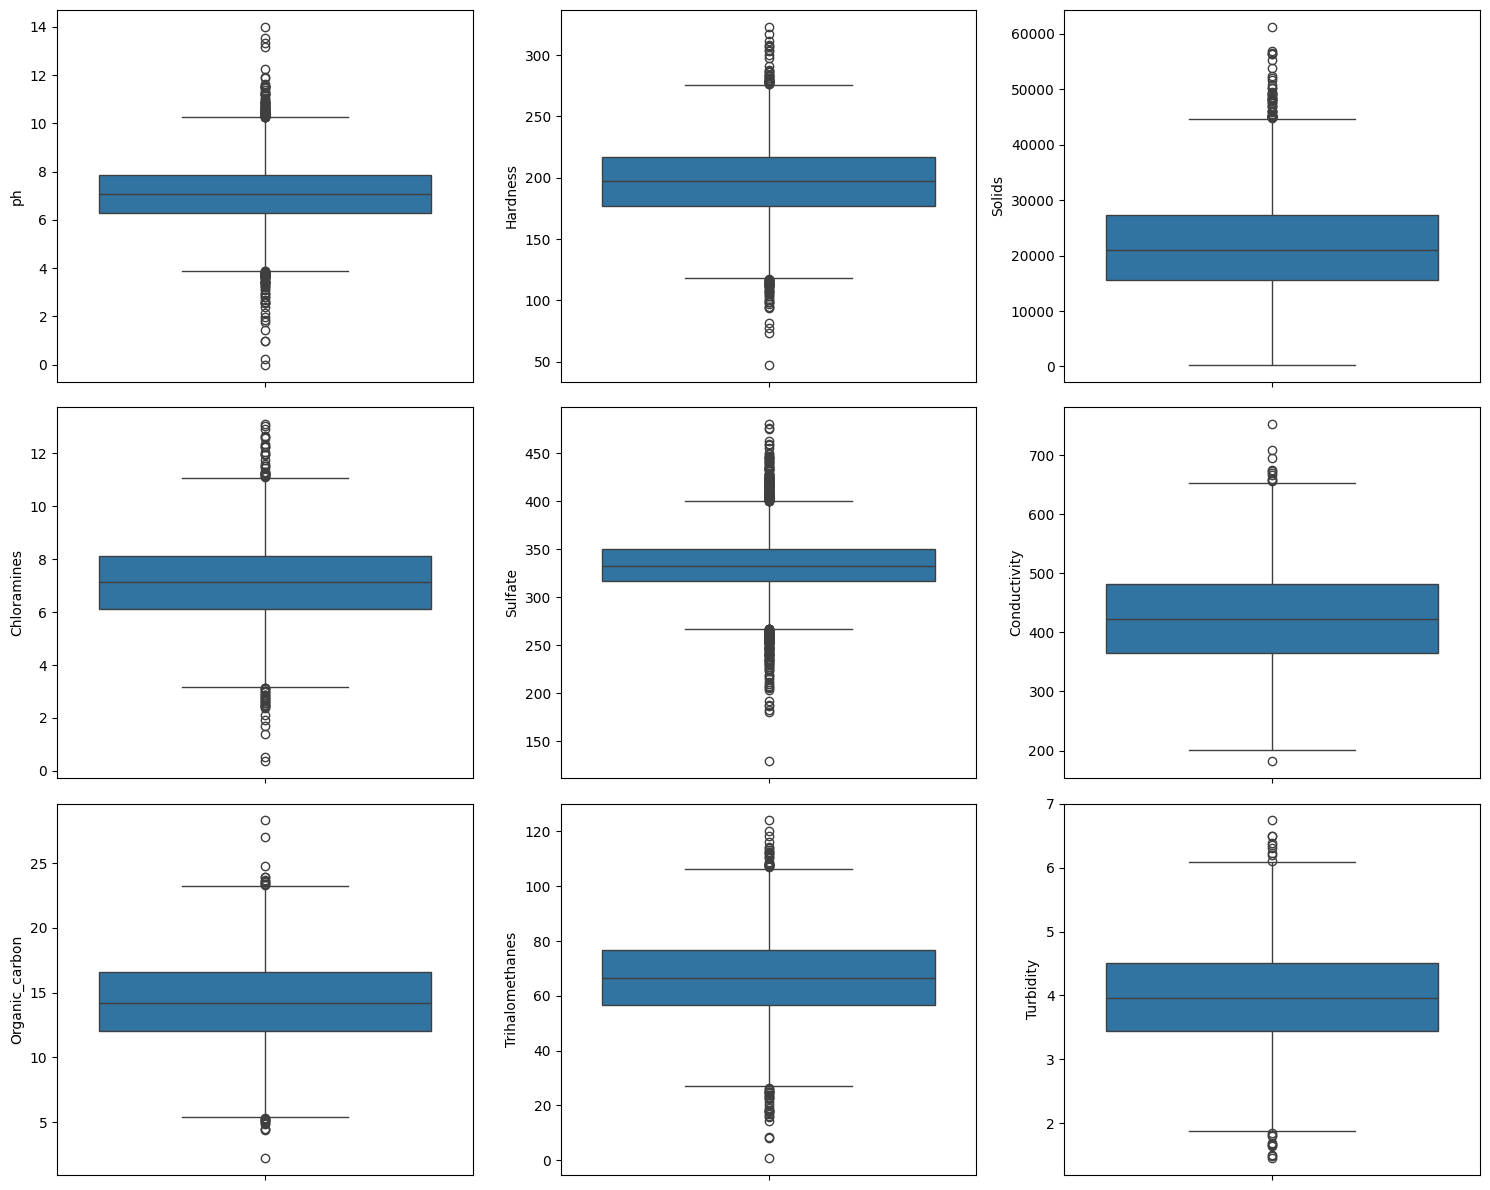

In [14]:
import seaborn as sns
columns = water_dataset.drop('Potability', axis=1).columns
cols = 3
rows = (len(columns) + cols -1 ) // cols
plt.figure(figsize=(cols*5, rows*4))
for i, column in enumerate(columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=water_dataset[column])
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [15]:
Q1 = water_dataset.quantile(0.25)
Q3 = water_dataset.quantile(0.75)
IQR = Q3 - Q1
outliers = ((water_dataset < (Q1 - 1.5*IQR)) | (water_dataset > (Q3 + 1.5*IQR))).sum()
print(outliers)

ph                 142
Hardness            83
Solids              47
Chloramines         61
Sulfate            264
Conductivity        11
Organic_carbon      25
Trihalomethanes     54
Turbidity           19
Potability           0
dtype: int64


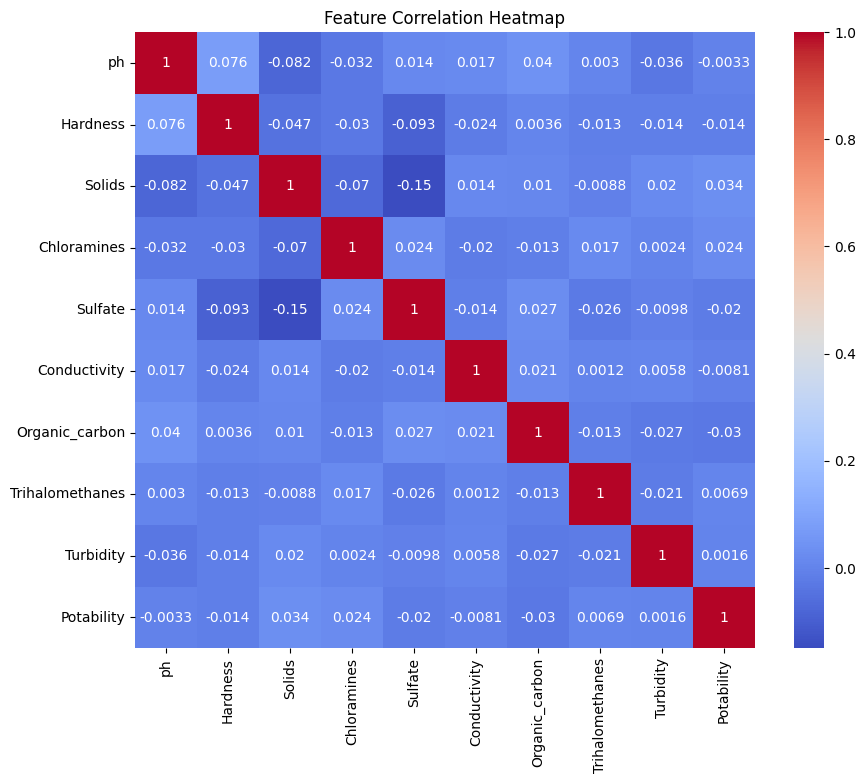

In [16]:
plt.figure(figsize=(10,8))
corr = water_dataset.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

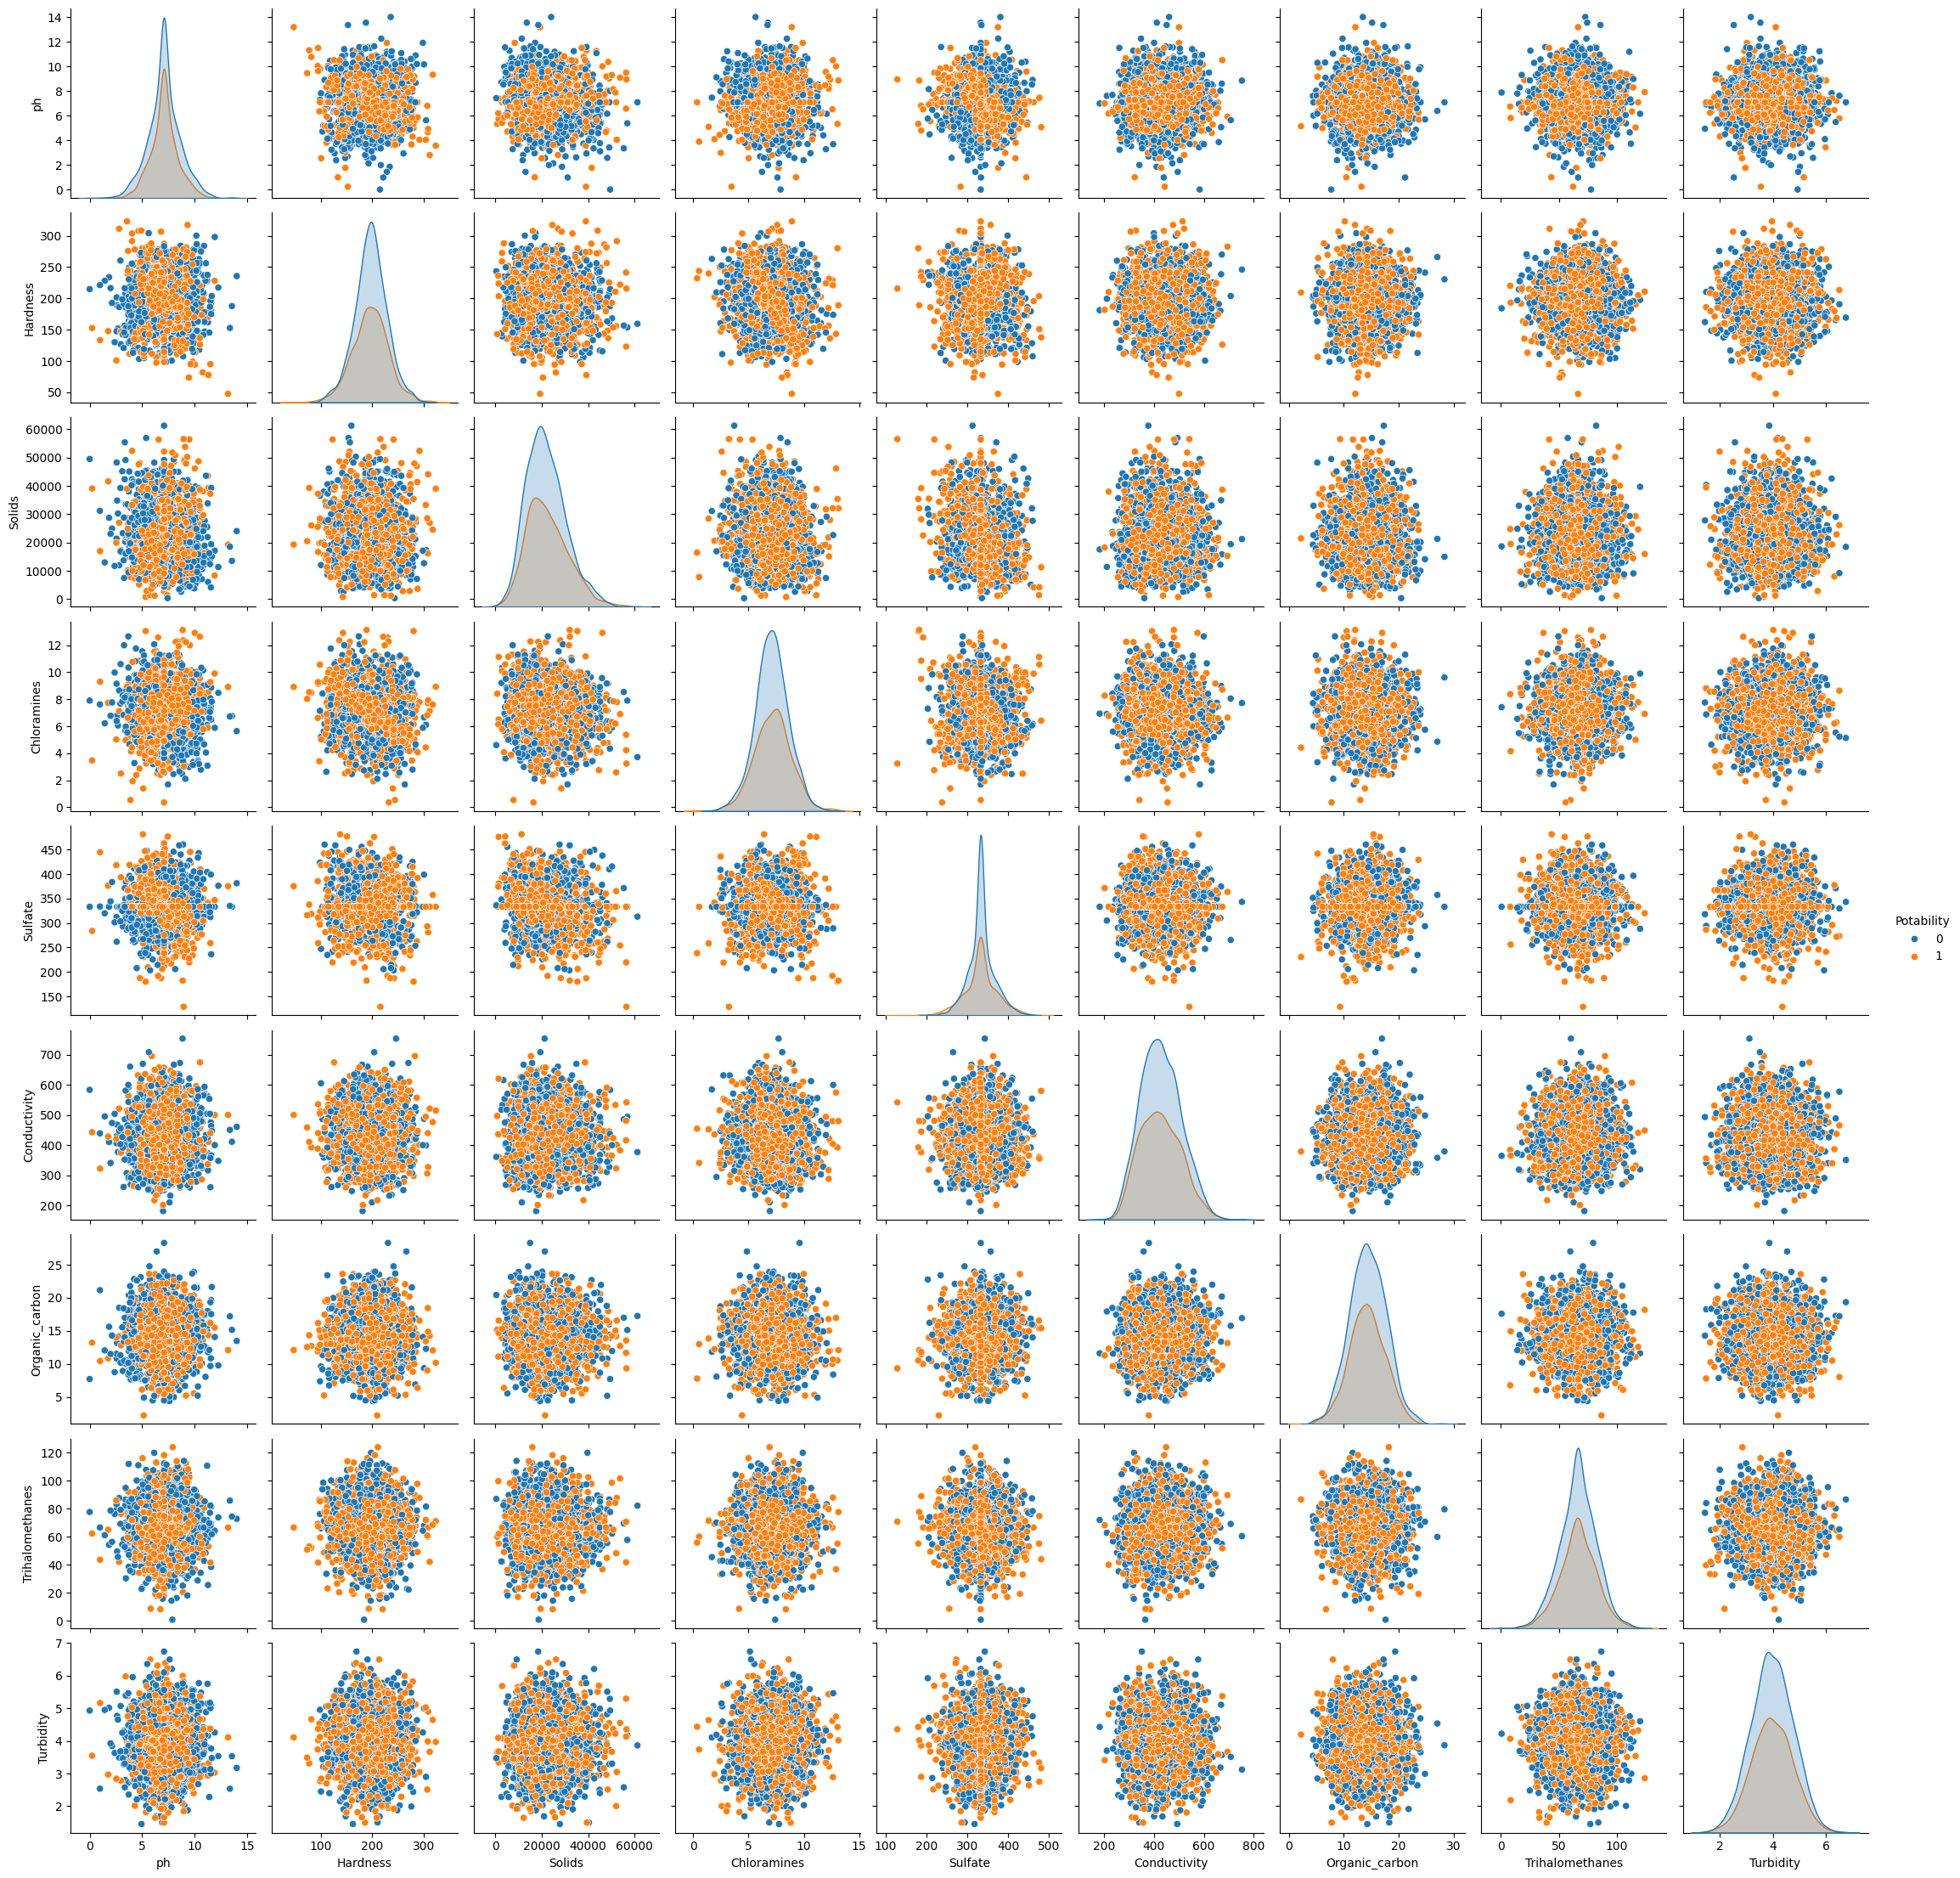

In [17]:
sns.pairplot(water_dataset, hue="Potability")
plt.show()

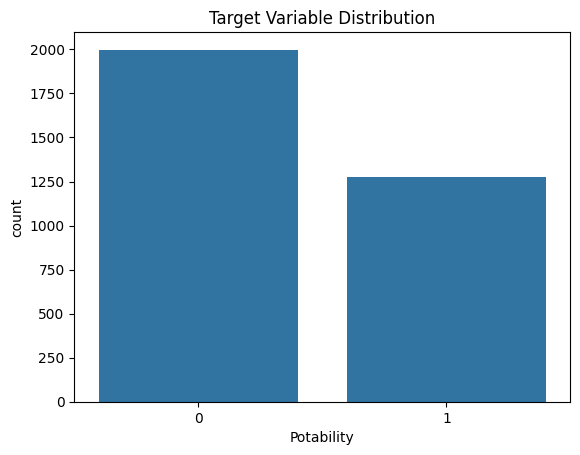

,proportion
Potability,
0,0.60989
1,0.39011


In [18]:
sns.countplot(x='Potability', data=water_dataset)
plt.title("Target Variable Distribution")
plt.show()

water_dataset['Potability'].value_counts(normalize=True)

# Data Preprocessing


In [19]:
X = water_dataset.drop('Potability', axis=1)
y = water_dataset['Potability']

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Modeling


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix


models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

In [30]:
model_results = {}
best_model_name = None
best_acc = 0
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    print(f"{name} Classification Report:\n", classification_report(y_test, y_pred))

    model_results[name] = {'Accuracy %': acc*100, 'ROC_AUC %': roc_auc*100}
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model = model


Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.52      0.57       400
           1       0.42      0.54      0.47       256

    accuracy                           0.53       656
   macro avg       0.53      0.53      0.52       656
weighted avg       0.55      0.53      0.53       656

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.80      0.72       400
           1       0.52      0.33      0.40       256

    accuracy                           0.62       656
   macro avg       0.58      0.57      0.56       656
weighted avg       0.60      0.62      0.59       656

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.70      0.68       400
           1       0.49      0.45      0.47       256

    accuracy                           0.60       656
   macro avg      

Model Performance Summary

                     Accuracy %  ROC_AUC %
Random Forest         67.225610  60.328125
KNN                   61.737805  56.531250
XGBoost               61.432927  56.843750
Decision Tree         60.213415  57.390625
Logistic Regression   52.743902  52.882812


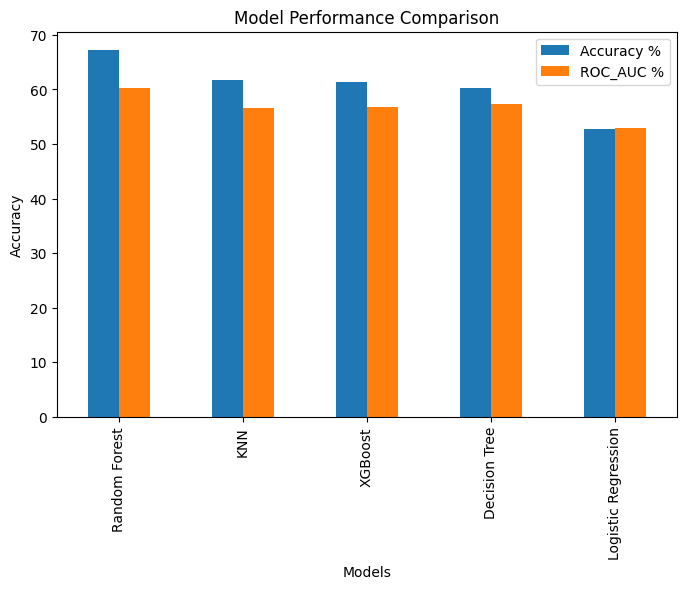

In [24]:
results_df = pd.DataFrame(model_results).T.sort_values(by='Accuracy %', ascending=False)
print('Model Performance Summary\n')
print(results_df)

results_df.plot(kind='bar', figsize=(8, 5))
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

In [32]:
import joblib
from google.colab import drive
drive.mount('/content/drive')
joblib.dump(best_model, "/content/drive/MyDrive/Aqua-Safe/aqua_safe_model.pkl")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['/content/drive/MyDrive/Aqua-Safe/aqua_safe_model.pkl']

# Results